In [1]:
!pip install opencv-python

In [2]:
# Download prototxt (working)
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/ssd_mobilenet_v1_coco.pbtxt -O MobileNetSSD_deploy.prototxt

# Download weights (working)
!wget https://github.com/opencv/opencv_3rdparty/raw/master/dnn/ssd_mobilenet_v1_coco_2017_11_17.pb -O MobileNetSSD_deploy.caffemodel

--2026-04-06 10:08:58--  https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/ssd_mobilenet_v1_coco.pbtxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-06 10:08:58 ERROR 404: Not Found.

--2026-04-06 10:08:58--  https://github.com/opencv/opencv_3rdparty/raw/master/dnn/ssd_mobilenet_v1_coco_2017_11_17.pb
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-06 10:08:58 ERROR 404: Not Found.



In [3]:
!pip install gdown

Loaded MobileNet-SSD model.
Skipping test image; file not found: test.jpg
Pseudo training workflow: integrate your dataset and transfer learning logic here.
# Example steps:
# 1. Build or load your base model (e.g., MobileNetV2) and add new heads.
# 2. Compile: model.compile(optimizer='adam', loss='categorical_crossentropy').
# 3. Fit with your training/validation generators.
# model.fit(train_data, epochs=10, validation_data=val_data)
Skipping actual training in this script.


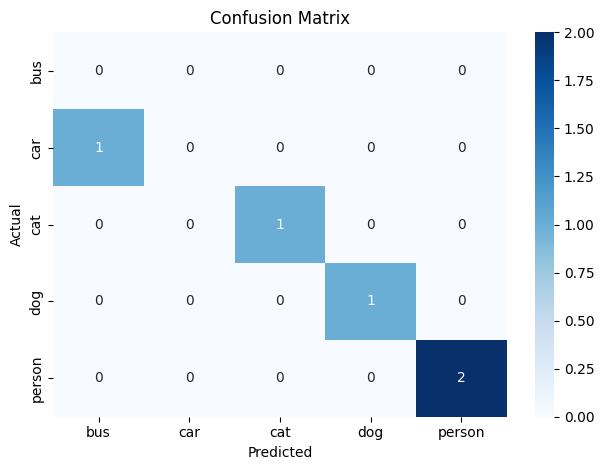


Classification Report:
              precision    recall  f1-score   support

         bus       0.00      0.00      0.00         0
         car       0.00      0.00      0.00         1
         cat       1.00      1.00      1.00         1
         dog       1.00      1.00      1.00         1
      person       1.00      1.00      1.00         2

    accuracy                           0.80         5
   macro avg       0.60      0.60      0.60         5
weighted avg       0.80      0.80      0.80         5



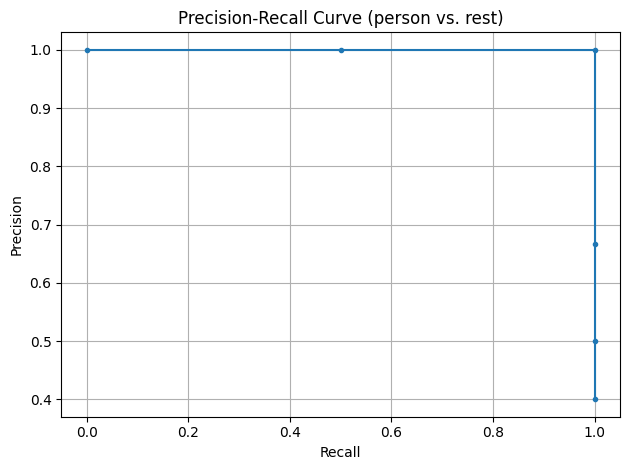

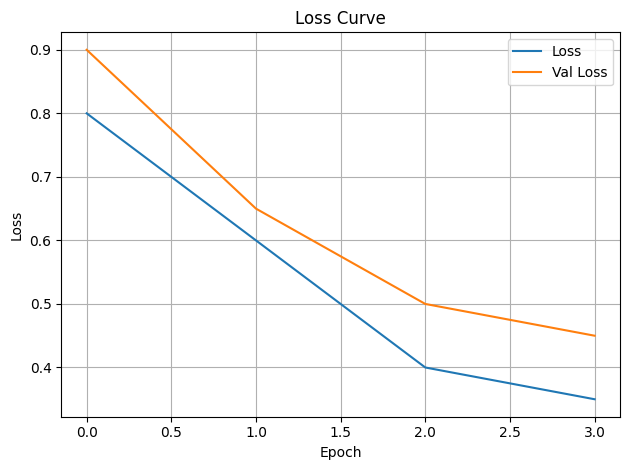

Skipping external image; file not found: external_image.jpg


In [4]:
import argparse
import os
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

CLASSES = [
    "background", "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow", "diningtable", "dog", "horse",
    "motorbike", "person", "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

MODEL_PROTOTXT = "MobileNetSSD_deploy.prototxt"
MODEL_WEIGHTS = "MobileNetSSD_deploy.caffemodel"

net = None


def load_detection_model():
    """Load the MobileNet-SSD model if the files exist."""
    global net

    missing = [p for p in (MODEL_PROTOTXT, MODEL_WEIGHTS) if not os.path.isfile(p)]
    if missing:
        raise FileNotFoundError("Missing model file(s): " + ", ".join(missing))

    net = cv2.dnn.readNetFromCaffe(MODEL_PROTOTXT, MODEL_WEIGHTS)
    print("Loaded MobileNet-SSD model.")
    return net


def detect_objects(frame):
    """Run object detection and draw boxes on the frame."""
    global net

    if net is None:
        raise RuntimeError("Detection model not loaded.")

    h, w = frame.shape[:2]
    blob = cv2.dnn.blobFromImage(frame, 0.007843, (300, 300), 127.5)

    net.setInput(blob)
    detections = net.forward()

    results = []

    for i in range(detections.shape[2]):
        confidence = float(detections[0, 0, i, 2])
        if confidence < 0.5:
            continue

        idx = int(detections[0, 0, i, 1])
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = box.astype("int")

        label = CLASSES[idx] if idx < len(CLASSES) else f"class-{idx}"

        results.append({
            "class_id": idx,
            "label": label,
            "confidence": confidence,
            "bbox": (startX, startY, endX, endY),
        })

        cv2.rectangle(frame, (startX, startY), (endX, endY), (0, 255, 0), 2)

        cv2.putText(
            frame,
            f"{label}: {confidence:.2f}",
            (startX, startY - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2
        )

    return frame, results


def pseudo_training_workflow():
    """Placeholder for transfer-learning training steps."""
    print("Pseudo training workflow: integrate your dataset and transfer learning logic here.")
    print("# Example steps:")
    print("# 1. Build or load your base model (e.g., MobileNetV2) and add new heads.")
    print("# 2. Compile: model.compile(optimizer='adam', loss='categorical_crossentropy').")
    print("# 3. Fit with your training/validation generators.")
    print("# model.fit(train_data, epochs=10, validation_data=val_data)")
    print("Skipping actual training in this script.")


def evaluate_classification(y_true, y_pred, y_scores):
    """Compute and plot evaluation metrics."""

    labels = sorted(set(y_true + y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(np.arange(len(labels)) + 0.5, labels)
    plt.yticks(np.arange(len(labels)) + 0.5, labels)
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    precision, recall, _ = precision_recall_curve(
        [1 if label == "person" else 0 for label in y_true],
        y_scores
    )

    plt.figure()
    plt.plot(recall, precision, marker=".")
    plt.title("Precision-Recall Curve (person vs. rest)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_loss_curve(history):
    """Plot training loss."""
    plt.figure()
    plt.plot(history["loss"], label="Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def run_video_inference(device_index=0):
    """Run webcam inference."""
    cap = cv2.VideoCapture(device_index)

    if not cap.isOpened():
        print(f"Unable to open video device {device_index}.")
        return

    print("Starting video inference. Press ESC to stop.")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        output, _ = detect_objects(frame)
        cv2.imshow("Video Detection", output)

        if cv2.waitKey(1) == 27:
            break

    cap.release()
    cv2.destroyAllWindows()


def load_image(path):
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Image not found: {path}")

    image = cv2.imread(path)
    if image is None:
        raise ValueError(f"Failed to load image: {path}")

    return image


def process_and_display(image_path, window_title):
    image = load_image(image_path)

    output, results = detect_objects(image.copy())
    print(f"{window_title} detections:", [(r["label"], r["confidence"]) for r in results])

    cv2.imshow(window_title, output)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    return results


def main():
    parser = argparse.ArgumentParser(
        description="MobileNet-SSD detection pipeline with evaluation plots."
    )

    parser.add_argument("--test-image", default="test.jpg")
    parser.add_argument("--external-image", default="external_image.jpg")
    parser.add_argument("--run-video", action="store_true")
    parser.add_argument("--video-device", type=int, default=0)

    args, unknown = parser.parse_known_args()

    try:
        load_detection_model()
    except FileNotFoundError as exc:
        print(exc)
        sys.exit(1)

    if os.path.isfile(args.test_image):
        process_and_display(args.test_image, "Detection")
    else:
        print(f"Skipping test image; file not found: {args.test_image}")

    pseudo_training_workflow()

    # Dummy evaluation data
    sample_ground_truth = ["person", "car", "dog", "person", "cat"]
    sample_predictions = ["person", "bus", "dog", "person", "cat"]
    sample_scores = [0.96, 0.42, 0.81, 0.88, 0.61]

    evaluate_classification(sample_ground_truth, sample_predictions, sample_scores)

    fake_history = {
        "loss": [0.8, 0.6, 0.4, 0.35],
        "val_loss": [0.9, 0.65, 0.5, 0.45]
    }

    plot_loss_curve(fake_history)

    if os.path.isfile(args.external_image):
        process_and_display(args.external_image, "External Inference")
    else:
        print(f"Skipping external image; file not found: {args.external_image}")

    if args.run_video:
        run_video_inference(args.video_device)


if __name__ == "__main__":
    main()